In [28]:
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter
import torchmetrics

torch.cuda.is_available()

True

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Device : cuda
True
NVIDIA GeForce RTX 3070 Laptop GPU


In [30]:
from torchvision.transforms import ToTensor, Normalize, Compose, Grayscale
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

# Définir le chemin du dataset
dataset_path = "./dataset"

image_mean = [0.5]
image_std  = [0.5]

transform = Compose([
    Grayscale(num_output_channels=1),
    ToTensor(),
    Normalize(mean=image_mean, std=image_std)
])

# Charger le dataset complet
full_dataset = ImageFolder(root=dataset_path, transform=transform)

# Afficher les informations du dataset
print(f"Nombre total d'images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")
print(f"Nombre de classes: {len(full_dataset.classes)}")

# Calculer les sizes pour train/test/validation (70/15/15)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
test_size = int(0.15 * total_size)
validation_size = total_size - train_size - test_size

print(f"\nRépartition des données:")
print(f"Train: {train_size} images (70%)")
print(f"Test: {test_size} images (15%)")
print(f"Validation: {validation_size} images (15%)")

# Diviser le dataset
dataset_train, dataset_test, dataset_validation = random_split(
    full_dataset, 
    [train_size, test_size, validation_size],
    generator=torch.Generator().manual_seed(42)  # Pour reproductibilité
)

print(f"\n✓ Datasets créés et normalisés avec succès!")
print(f"Train: {len(dataset_train)} images")
print(f"Test: {len(dataset_test)} images")
print(f"Validation: {len(dataset_validation)} images")

Nombre total d'images: 1941408
Classes: ['The Eiffel Tower', 'airplane', 'alarm clock', 'ant', 'apple', 'axe', 'bee', 'bicycle', 'bush', 'cactus', 'crown', 'dolphin', 'dragon', 'penguin', 'star']
Nombre de classes: 15

Répartition des données:
Train: 1358985 images (70%)
Test: 291211 images (15%)
Validation: 291212 images (15%)

✓ Datasets créés et normalisés avec succès!
Train: 1358985 images
Test: 291211 images
Validation: 291212 images


Type du tensor: <class 'torch.Tensor'>
Shape du tensor: torch.Size([1, 64, 64])
Min value: -1.0000, Max value: 1.0000
Label: cactus (index: 9)


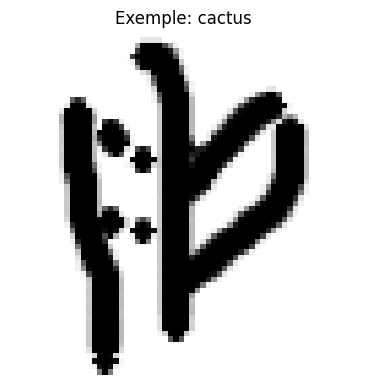

In [31]:
sample_image, sample_label = dataset_train[0]

print(f"Type du tensor: {type(sample_image)}")
print(f"Shape du tensor: {sample_image.shape}")
print(f"Min value: {sample_image.min().item():.4f}, Max value: {sample_image.max().item():.4f}")
print(f"Label: {full_dataset.classes[sample_label]} (index: {sample_label})")

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
# Dénormaliser pour affichage (passer de [-1, 1] à [0, 1])
img_display = (sample_image + 1) / 2
img_display = img_display.squeeze(0).numpy()
ax.imshow(img_display, cmap='gray')
ax.set_title(f"Exemple: {full_dataset.classes[sample_label]}")
ax.axis('off')
plt.tight_layout()
plt.show()

In [32]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)
dataloader_validation = DataLoader(dataset_validation, batch_size=64, shuffle=False)

In [33]:
train_features, train_labels = next(iter(dataloader_train))
train_features.size()

torch.Size([64, 1, 64, 64])

## batch de 64 images à 1 canal de couleur de taill 64*64

In [34]:
from torch import nn

def forward():
    features = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 1 canal pour image en niveaux de gris
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 64x64 -> 32x32
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 32x32 -> 16x16
    )

    classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * 16 * 16, 128),  # 64 canaux * 16*16 = 16384
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 15)  # 15 classes
    )

    return nn.Sequential(features, classifier)

In [35]:
model = forward().to(device)

print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParamètres entraînables : {n_params:,}")

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=15, bias=True)
  )
)

Paramètres entraînables : 2,118,223


In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [37]:
log_dir = os.path.join("runs")
writer = SummaryWriter(log_dir=log_dir)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "test_f1": [],
    "test_precision": [],
    "test_recall": [],
    "batch_step": [],
    "batch_loss": [],
    "batch_acc": [],
}

global_step = 0

In [38]:
def train_loop(dataloader, model, loss_fn, optimizer, writer=None, history=None, global_step=0):
    size = len(dataloader.dataset)
    model.train()
    num_batches = len(dataloader)
    running_loss = 0.0
    running_correct = 0
    loop = tqdm(enumerate(dataloader), total=num_batches, desc="Train", leave=False)
    for batch, (X, y_true) in loop:
        X = X.to(device)
        y_true = y_true.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y_true)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        batch_loss = loss.item()
        batch_correct = (y_pred.argmax(1) == y_true).sum().item()
        batch_acc = batch_correct / X.size(0)
        running_loss += batch_loss
        running_correct += batch_correct

        if writer is not None:
            writer.add_scalar("Batch/Loss", batch_loss, global_step)
            writer.add_scalar("Batch/Accuracy", batch_acc, global_step)
        if history is not None:
            history["batch_step"].append(global_step)
            history["batch_loss"].append(batch_loss)
            history["batch_acc"].append(batch_acc)

        # Met à jour la barre et affiche la perte actuelle
        current = batch * getattr(dataloader, 'batch_size', X.size(0)) + X.size(0)
        loop.set_postfix({'loss': f"{batch_loss:.4f}", 'samples': f"{current}/{size}"})
        global_step += 1

    avg_loss = running_loss / num_batches
    accuracy = running_correct / size
    return avg_loss, accuracy, global_step

def test_loop(dataloader, model, loss_fn, num_classes=15):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
    recall    = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
    f1        = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)
    confmat   = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

    loop = tqdm(enumerate(dataloader), total=num_batches, desc="Test", leave=False)
    with torch.no_grad():
        for batch, (X, y_true) in loop:
            X = X.to(device)
            y_true = y_true.to(device)

            y_pred = model(X)
            test_loss += loss_fn(y_pred, y_true).item()

            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()
            avg_loss = test_loss / (batch + 1)
            acc = correct / ((batch + 1) * getattr(dataloader, 'batch_size', X.size(0)))
            loop.set_postfix({'avg_loss': f"{avg_loss:.4f}", 'acc': f"{100*acc:.1f}%"})

            preds = y_pred.argmax(dim=1)
            accuracy.update(preds, y_true)
            precision.update(preds, y_true)
            recall.update(preds, y_true)
            f1.update(preds, y_true)
            confmat.update(preds, y_true)
    
    test_loss /= num_batches
    correct /= size

    metrics = {
        "loss":      test_loss,
        "accuracy":  accuracy.compute().item(),
        "precision": precision.compute().item(),
        "recall":    recall.compute().item(),
        "f1":        f1.compute().item(),
        "confmat":   confmat.compute().cpu(),
    }
    accuracy.reset(); precision.reset(); recall.reset(); f1.reset(); confmat.reset()
    return test_loss, correct, metrics

def plot_epoch_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["test_loss"], marker="o", label="test")
    axes[0].set_title("Loss par epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_acc"], marker="o", label="train")
    axes[1].plot(history["epoch"], history["test_acc"], marker="o", label="test")
    axes[1].set_title("Accuracy par epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    return fig


def plot_batch_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["batch_step"], history["batch_loss"], color="tab:blue", linewidth=1)
    axes[0].set_title("Loss tout du long")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["batch_step"], history["batch_acc"], color="tab:orange", linewidth=1)
    axes[1].set_title("Accuracy tout du long")
    axes[1].set_xlabel("Batch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

In [39]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, model=None, path="best_model.pt"):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = None
        self.stop      = False
        self.model     = model
        self.path      = path

    def step(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            if self.model is not None:
                torch.save(self.model.state_dict(), self.path)
                print(f"  ✓ Meilleur modèle sauvegardé (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [40]:
epochs = 500
global_step = 0
early_stopping = EarlyStopping(patience=5, min_delta=1e-4, model=model, path="best_model.pt")

for epoch in range(epochs):
    epoch_index = epoch + 1
    print("Epoch :", epoch_index)

    train_loss, train_acc, global_step = train_loop(
        dataloader_train,
        model,
        criterion,
        optimizer,
        writer=writer,
        history=history,
        global_step=global_step,
    )
    test_loss, test_acc, metrics = test_loop(dataloader_test, model, criterion)
    scheduler.step()
    print(f"LR = {scheduler.get_last_lr()[0]:.6f}")

    history["epoch"].append(epoch_index)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(metrics["loss"])
    history["test_acc"].append(metrics["accuracy"])
    history["test_f1"].append(metrics["f1"])
    history["test_precision"].append(metrics["precision"])
    history["test_recall"].append(metrics["recall"])

    print(
        f"train - loss: {train_loss:.4f}, train - acc: {100 * train_acc:.2f}% | "
        f"test - loss: {test_loss:.4f}, test - acc: {100 * test_acc:.2f}%"
        f"| F1: {metrics['f1']:.4f} | precision: {metrics['precision']:.4f} | recall: {metrics['recall']:.4f}"
    )

    writer.add_scalars("Epoch/Loss", {"train": train_loss, "test": test_loss}, epoch_index)
    writer.add_scalars("Epoch/Accuracy", {"train": train_acc, "test": test_acc}, epoch_index)

    epoch_fig = plot_epoch_history(history)
    writer.add_figure("Figures/Epoch overview", epoch_fig, global_step=epoch_index)
    plt.show()
    plt.close(epoch_fig)
    writer.flush()

    early_stopping.step(test_loss)
    if early_stopping.stop: 
        print(f"Entraînement stoppé à l'epoch {epoch_index} (patience={early_stopping.patience})")
        model.load_state_dict(torch.load("best_model.pt", map_location=device))
        print("  ✓ Meilleurs poids restaurés depuis best_model.pt")
        break

batch_fig = plot_batch_history(history)
writer.add_figure("Figures/Batch overview", batch_fig, global_step=global_step)
plt.show()
plt.close(batch_fig)
writer.flush()
writer.close()

Epoch : 1


LR = 0.001000
train - loss: 0.4168, train - acc: 87.16% | test - loss: 0.2275, test - acc: 93.03%| F1: 0.9267 | precision: 0.9289 | recall: 0.9262
  ✓ Meilleur modèle sauvegardé (val_loss=0.2275)
Epoch : 2


LR = 0.001000
train - loss: 0.2545, train - acc: 92.26% | test - loss: 0.1917, test - acc: 94.13%| F1: 0.9376 | precision: 0.9375 | recall: 0.9382
  ✓ Meilleur modèle sauvegardé (val_loss=0.1917)
Epoch : 3


LR = 0.001000
train - loss: 0.2133, train - acc: 93.43% | test - loss: 0.1710, test - acc: 94.74%| F1: 0.9443 | precision: 0.9450 | recall: 0.9440
  ✓ Meilleur modèle sauvegardé (val_loss=0.1710)
Epoch : 4


LR = 0.001000
train - loss: 0.1932, train - acc: 93.99% | test - loss: 0.1748, test - acc: 94.66%| F1: 0.9429 | precision: 0.9430 | recall: 0.9434
Epoch : 5


...

LR = 0.001000
train - loss: 0.1671, train - acc: 94.70% | test - loss: 0.1626, test - acc: 95.00%| F1: 0.9468 | precision: 0.9466 | recall: 0.9471
Epoch : 9


LR = 0.001000
train - loss: 0.1636, train - acc: 94.79% | test - loss: 0.1651, test - acc: 94.96%| F1: 0.9466 | precision: 0.9471 | recall: 0.9463
Epoch : 10


LR = 0.001000
train - loss: 0.1622, train - acc: 94.81% | test - loss: 0.1686, test - acc: 94.82%| F1: 0.9452 | precision: 0.9459 | recall: 0.9448
Epoch : 11


LR = 0.001000
train - loss: 0.1601, train - acc: 94.90% | test - loss: 0.1616, test - acc: 95.04%| F1: 0.9473 | precision: 0.9477 | recall: 0.9471
Epoch : 12


LR = 0.001000
train - loss: 0.1592, train - acc: 94.92% | test - loss: 0.1615, test - acc: 95.10%| F1: 0.9481 | precision: 0.9478 | recall: 0.9485
Entraînement stoppé à l'epoch 12 (patience=5)
  ✓ Meilleurs poids restaurés depuis best_model.pt


In [41]:
# Validation sur le dataset de validation
print("\n" + "="*80)
print("VALIDATION SUR LE DATASET DE VALIDATION")
print("="*80 + "\n")

val_loss, val_acc, val_metrics = test_loop(dataloader_validation, model, criterion)

print(f"\nRésultats de validation:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {100 * val_acc:.2f}%")
print(f"F1-Score: {val_metrics['f1']:.4f}")
print(f"Precision: {val_metrics['precision']:.4f}")
print(f"Recall: {val_metrics['recall']:.4f}")


VALIDATION SUR LE DATASET DE VALIDATION




Résultats de validation:
Loss: 0.1607
Accuracy: 95.04%
F1-Score: 0.9472
Precision: 0.9470
Recall: 0.9475


In [47]:
# Charger les meilleurs poids avant l'export
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print("✓ Meilleurs poids chargés depuis best_model.pt")

torch_model = model
example_inputs = (torch.randn(1, 1, 64, 64).to(device),)
torch.onnx.export(
    model,
    example_inputs,
    "deep_learning_drawing_game.onnx",
    dynamo=False,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    opset_version=17,
)
print("✓ Modèle exporté : deep_learning_drawing_game.onnx")

✓ Meilleurs poids chargés depuis best_model.pt
✓ Modèle exporté : deep_learning_drawing_game.onnx


/tmp/ipykernel_61487/3310026031.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


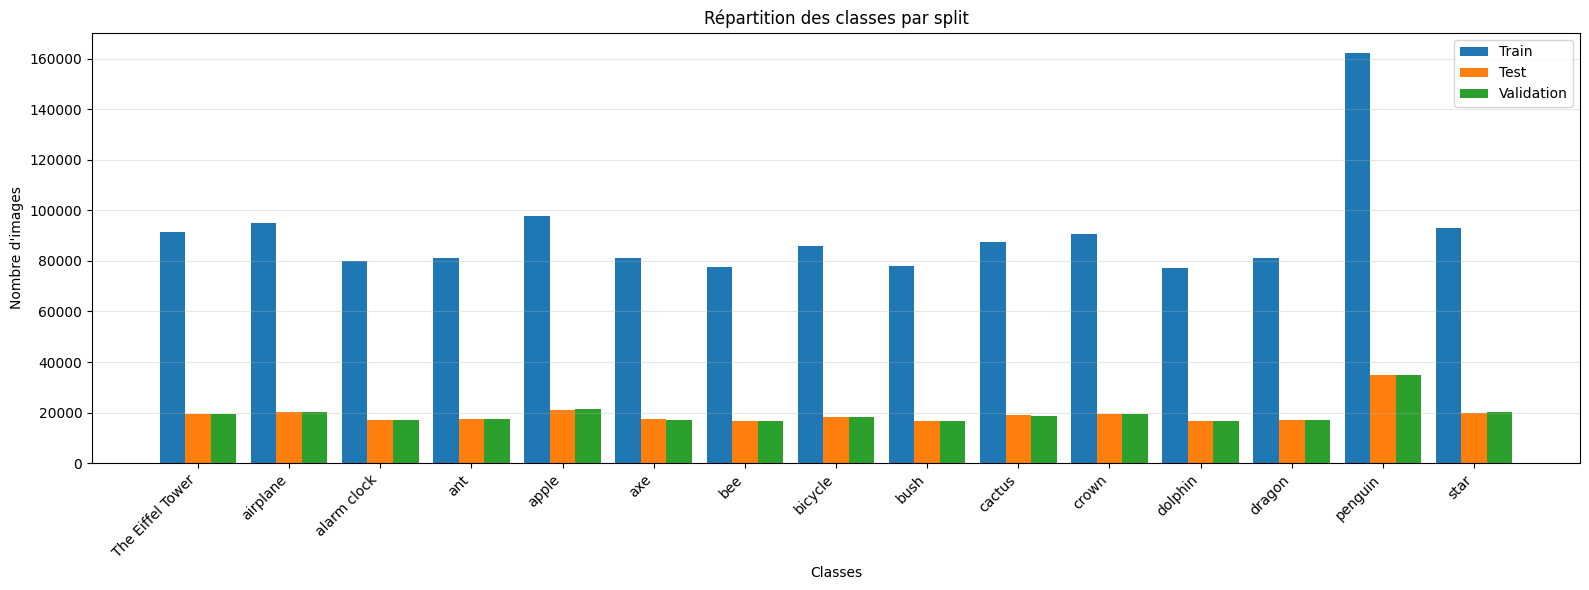

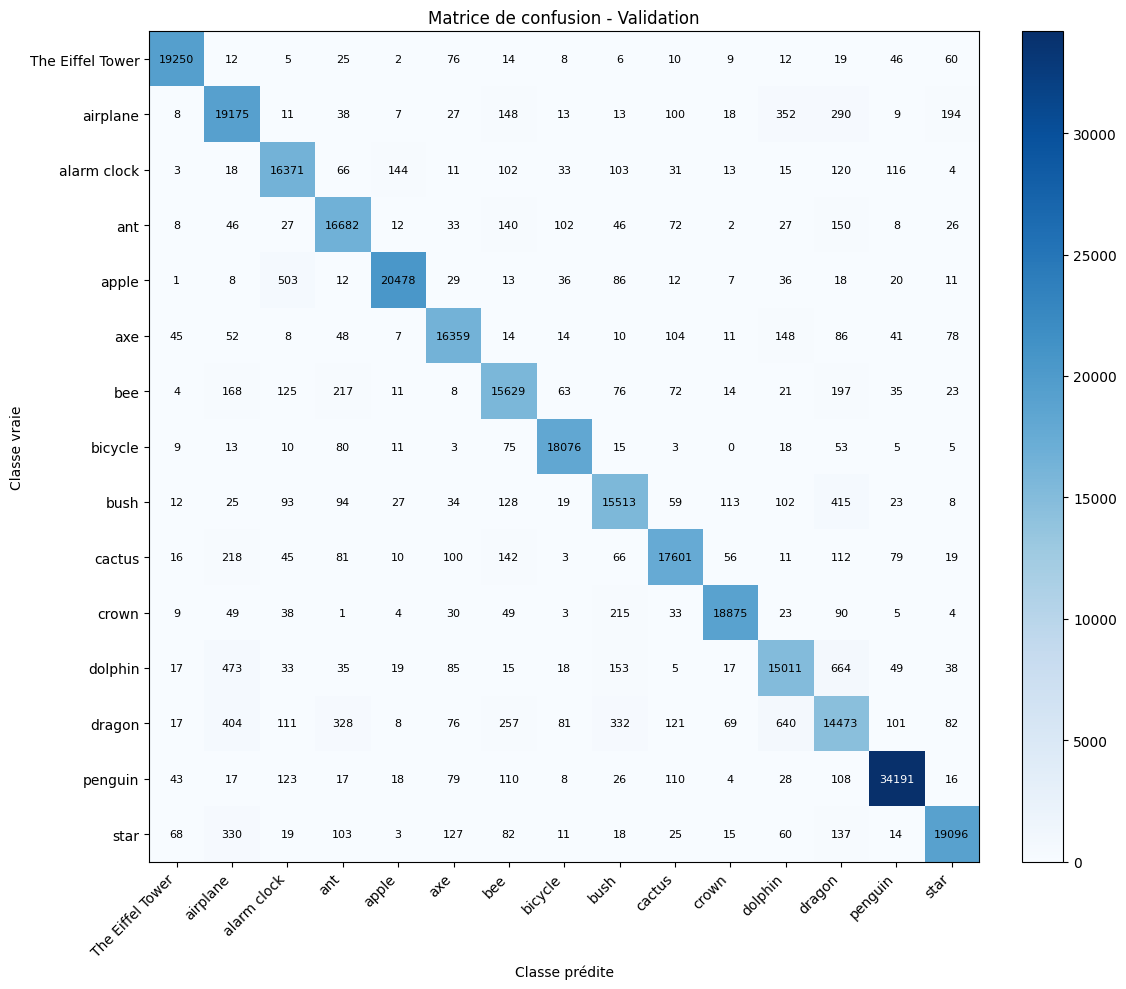

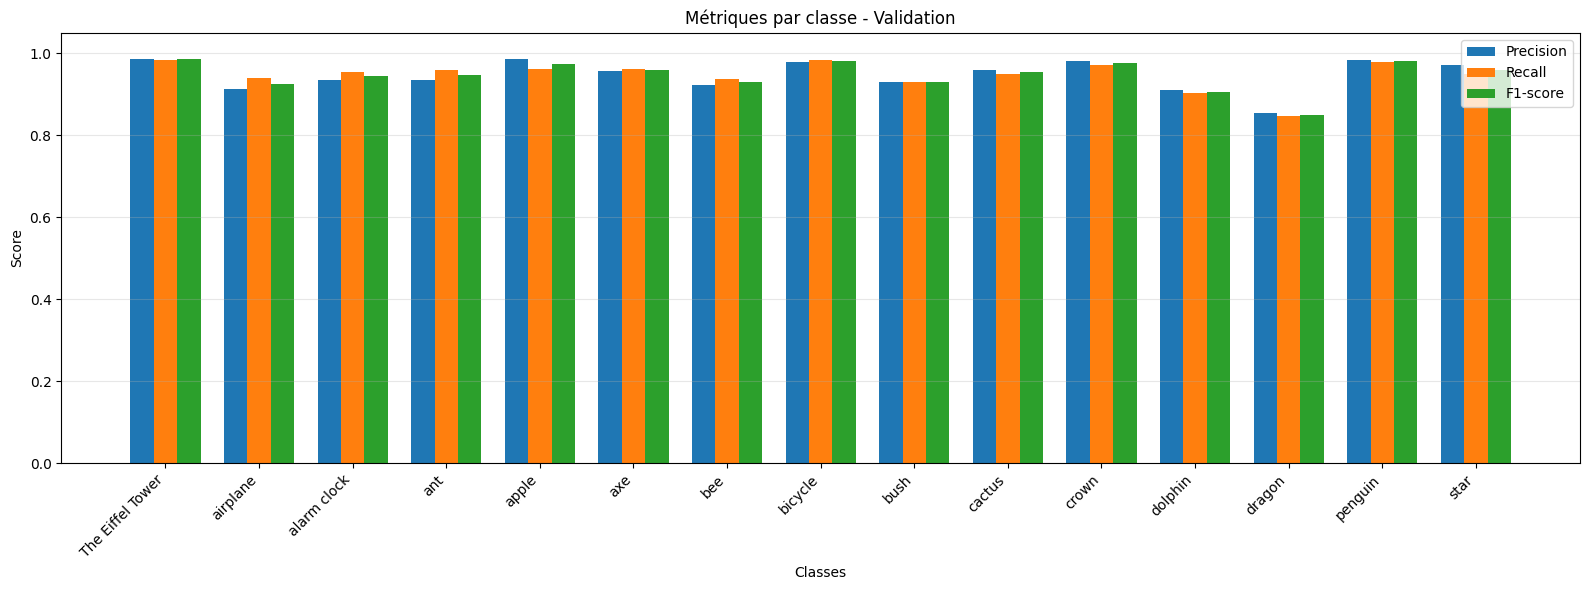

In [48]:
# Graphiques complémentaires utiles : répartition des classes, matrice de confusion et métriques par classe

class_names = full_dataset.classes
num_classes = len(class_names)

def get_subset_class_counts(subset, targets, num_classes):
    indices = np.array(subset.indices)
    subset_targets = np.array(targets)[indices]
    return np.bincount(subset_targets, minlength=num_classes)

def plot_class_distribution():
    train_counts = get_subset_class_counts(dataset_train, full_dataset.targets, num_classes)
    test_counts = get_subset_class_counts(dataset_test, full_dataset.targets, num_classes)
    val_counts = get_subset_class_counts(dataset_validation, full_dataset.targets, num_classes)

    x = np.arange(num_classes)
    width = 0.28

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - width, train_counts, width, label="Train")
    ax.bar(x, test_counts, width, label="Test")
    ax.bar(x + width, val_counts, width, label="Validation")

    ax.set_title("Répartition des classes par split")
    ax.set_xlabel("Classes")
    ax.set_ylabel("Nombre d'images")
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(confmat):
    cm = confmat.cpu().numpy()
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Matrice de confusion - Validation")
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe vraie")

    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    thresh = cm.max() * 0.6
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_per_class_metrics(confmat):
    cm = confmat.cpu().numpy().astype(np.float64)
    tp = np.diag(cm)
    precision = tp / np.maximum(cm.sum(axis=0), 1)
    recall = tp / np.maximum(cm.sum(axis=1), 1)
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    x = np.arange(num_classes)
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - width, precision, width, label="Precision")
    ax.bar(x, recall, width, label="Recall")
    ax.bar(x + width, f1, width, label="F1-score")

    ax.set_title("Métriques par classe - Validation")
    ax.set_xlabel("Classes")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_class_distribution()
plot_confusion_matrix(val_metrics["confmat"])
plot_per_class_metrics(val_metrics["confmat"])